In [12]:
import pandas as pd
import glob
import os
import re
import matplotlib.pyplot as plt

In [13]:
ordner_maennlich = r"D:\InfoVis\Neuer Ordner\Projekt\data_excels\Männliche Studierende"
ordner_weiblich = r"D:\InfoVis\Neuer Ordner\Projekt\data_excels\Weibliche Studierende"

datei_maennlich_25 = r"D:\InfoVis\wise24 - wise25\wise24 - wise25\männliche_Studierende_Köpfe.csv"
datei_weiblich_25 = r"D:\InfoVis\wise24 - wise25\wise24 - wise25\weibliche_Studierende_Köpfe.csv"

# Dateien sammeln
dateien_maennlich = glob.glob(os.path.join(ordner_maennlich, "*.csv"))
dateien_weiblich = glob.glob(os.path.join(ordner_weiblich, "*.csv"))

dateien_maennlich = [
    f for f in dateien_maennlich
    if os.path.basename(f).lower().startswith("sose") or os.path.basename(f).lower().startswith("wise")
]

dateien_weiblich = [
    f for f in dateien_weiblich
    if os.path.basename(f).lower().startswith("sose") or os.path.basename(f).lower().startswith("wise")
]

# Daten für männlich erstellen
liste_maennlich = []

for datei in sorted(dateien_maennlich):
    name = os.path.basename(datei).lower().replace(".csv", "")

    if name.startswith("sose"):
        jahr = 2000 + int(re.findall(r"\d+", name)[0])
        semester = "Sommer"
    elif name.startswith("wise"):
        zahl = re.findall(r"\d+", name)[0]
        jahr = 2000 + int(zahl[:2])
        semester = "Winter"
    else:
        continue

    df = pd.read_csv(datei, sep=";")
    df.columns = df.columns.str.strip()

    if "Column26" in df.columns:
        df["Column26"] = pd.to_numeric(df["Column26"], errors="coerce")

        eintrag = {
            "Jahr": jahr,
            "Semester": semester,
            "Geschlecht": "Männlich",
            "Summe_Koepfe": df["Column26"].sum()
        }

        liste_maennlich.append(eintrag)

df_maennlich = pd.DataFrame(liste_maennlich)

# Daten für weiblich erstellen
liste_weiblich = []

for datei in sorted(dateien_weiblich):
    name = os.path.basename(datei).lower().replace(".csv", "")

    if name.startswith("sose"):
        jahr = 2000 + int(re.findall(r"\d+", name)[0])
        semester = "Sommer"
    elif name.startswith("wise"):
        zahl = re.findall(r"\d+", name)[0]
        jahr = 2000 + int(zahl[:2])
        semester = "Winter"
    else:
        continue

    df = pd.read_csv(datei, sep=";")
    df.columns = df.columns.str.strip()

    if "Column26" in df.columns:
        df["Column26"] = pd.to_numeric(df["Column26"], errors="coerce")

        eintrag = {
            "Jahr": jahr,
            "Semester": semester,
            "Geschlecht": "Weiblich",
            "Summe_Koepfe": df["Column26"].sum()
        }

        liste_weiblich.append(eintrag)

df_weiblich = pd.DataFrame(liste_weiblich)

# Daten 2024/2025 vorbereiten
maennlich_25 = pd.read_csv(datei_maennlich_25, sep=";")
maennlich_25.columns = maennlich_25.columns.str.strip()
maennlich_25 = maennlich_25[["Jahr", "Semester", "Summe_Koepfe"]].copy()
maennlich_25["Geschlecht"] = "Männlich"
maennlich_25["Jahr"] = pd.to_numeric(maennlich_25["Jahr"], errors="coerce")
maennlich_25["Summe_Koepfe"] = pd.to_numeric(maennlich_25["Summe_Koepfe"], errors="coerce")
maennlich_25 = maennlich_25.dropna(subset=["Jahr", "Semester", "Summe_Koepfe"])

weiblich_25 = pd.read_csv(datei_weiblich_25, sep=";")
weiblich_25.columns = weiblich_25.columns.str.strip()
weiblich_25 = weiblich_25[["Jahr", "Semester", "Summe_Koepfe"]].copy()
weiblich_25["Geschlecht"] = "Weiblich"
weiblich_25["Jahr"] = pd.to_numeric(weiblich_25["Jahr"], errors="coerce")
weiblich_25["Summe_Koepfe"] = pd.to_numeric(weiblich_25["Summe_Koepfe"], errors="coerce")
weiblich_25 = weiblich_25.dropna(subset=["Jahr", "Semester", "Summe_Koepfe"])


df_geschlecht = pd.concat(
    [df_maennlich, df_weiblich, maennlich_25, weiblich_25],
    ignore_index=True
)

df_geschlecht["Jahr"] = df_geschlecht["Jahr"].astype(int)

df_geschlecht = (
    df_geschlecht
    .groupby(["Jahr", "Semester", "Geschlecht"], as_index=False)["Summe_Koepfe"]
    .sum()
    .sort_values(["Jahr", "Semester", "Geschlecht"])
    .reset_index(drop=True)
)

print(df_geschlecht)

    Jahr Semester Geschlecht  Summe_Koepfe
0   2016   Winter   Männlich        1553.0
1   2016   Winter   Weiblich        1643.0
2   2017   Sommer   Männlich        1479.0
3   2017   Sommer   Weiblich        1574.0
4   2017   Winter   Männlich        1552.0
5   2017   Winter   Weiblich        1700.0
6   2018   Sommer   Männlich        1362.0
7   2018   Sommer   Weiblich        1523.0
8   2018   Winter   Männlich        1414.0
9   2018   Winter   Weiblich        1625.0
10  2019   Sommer   Männlich        1282.0
11  2019   Sommer   Weiblich        1550.0
12  2019   Winter   Männlich        1375.0
13  2019   Winter   Weiblich        1675.0
14  2020   Sommer   Männlich        1253.0
15  2020   Sommer   Weiblich        1550.0
16  2020   Winter   Männlich        1391.0
17  2020   Winter   Weiblich        1667.0
18  2021   Sommer   Männlich        1270.0
19  2021   Sommer   Weiblich        1592.0
20  2021   Winter   Männlich        1305.0
21  2021   Winter   Weiblich        1662.0
22  2022   

In [14]:
# Pivot für Visualisierung
df_pivot = (
    df_geschlecht
    .pivot_table(index=["Jahr", "Semester"], columns="Geschlecht", values="Summe_Koepfe")
    .reset_index()
)

df_pivot["Jahr"] = df_pivot["Jahr"].astype(int)
df_pivot["Semester_Reihenfolge"] = df_pivot["Semester"].map({"Sommer": 0, "Winter": 1})
df_pivot = df_pivot.sort_values(["Jahr", "Semester_Reihenfolge"]).reset_index(drop=True)

df_pivot["Periode_kurz"] = df_pivot["Jahr"].astype(str) + "_" + df_pivot["Semester"].str[0]



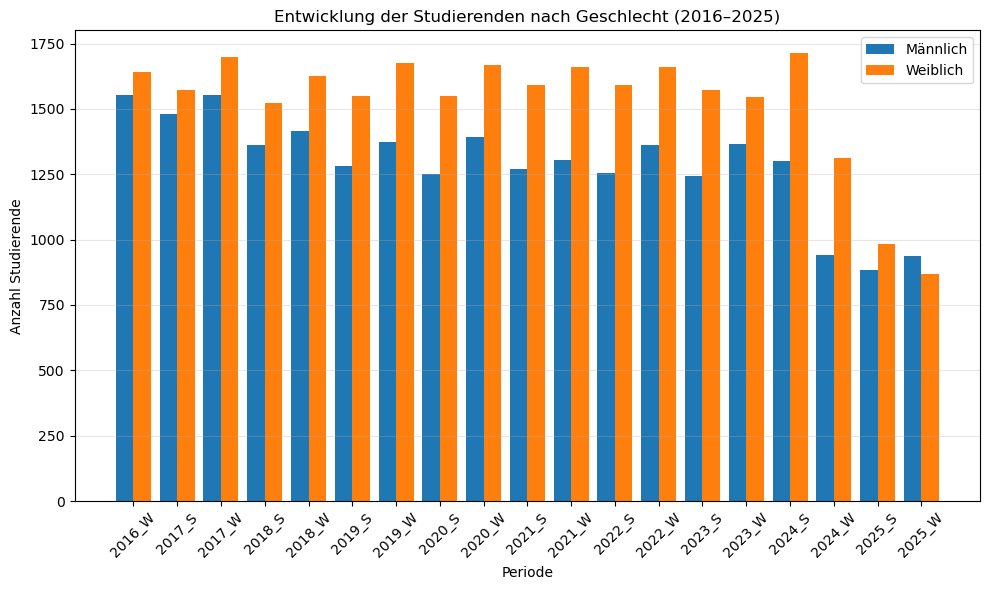

In [15]:
# Plot erstellen
plt.figure(figsize=(10, 6))

x = range(len(df_pivot))
width = 0.4

plt.bar(
    [i - width/2 for i in x],
    df_pivot["Männlich"],
    width=width,
    label="Männlich"
)

plt.bar(
    [i + width/2 for i in x],
    df_pivot["Weiblich"],
    width=width,
    label="Weiblich"
)

plt.xticks(x, df_pivot["Periode_kurz"], rotation=45)
plt.xlabel("Periode")
plt.ylabel("Anzahl Studierende")
plt.title("Entwicklung der Studierenden nach Geschlecht (2016–2025)")
plt.legend()
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

## Bildbeschreibung

Die Grafik zeigt die Entwicklung der Anzahl männlicher und weiblicher Studierender von 2016 bis 2025 in Form eines Balkendiagramms. Dabei werden sowohl Sommer- als auch Wintersemester berücksichtigt.
Es ist deutlich erkennbar, dass die Anzahl der weiblichen Studierenden in den meisten Semestern über der der männlichen liegt. Dieser Unterschied bleibt über den gesamten Zeitraum hinweg relativ konstant. Zudem zeigen die Balken, dass die Werte im Wintersemester in der Regel höher sind als im Sommersemester.
Im Zeitraum von 2016 bis etwa 2023 bleiben die Studierendenzahlen insgesamt auf einem ähnlichen Niveau, wobei es nur zu leichten Schwankungen kommt. Ein klarer langfristiger Trend ist in diesem Abschnitt nicht erkennbar. Auffällig ist jedoch der deutliche Rückgang ab dem Jahr 2024, der sich im Jahr 2025 weiter verstärkt. Diese Entwicklung sollte vorsichtig interpretiert werden, da die Daten für diese Jahre möglicherweise noch nicht vollständig vorliegen.
Die Darstellung als Balkendiagramm ermöglicht einen direkten Vergleich zwischen den Geschlechtern sowie zwischen den einzelnen Semestern und macht Unterschiede besonders gut sichtbar.

## Sprechtext 
Diese Folie zeigt die Entwicklung der Anzahl männlicher und weiblicher Studierender von 2016 bis 2025. Ziel ist es, Unterschiede zwischen den Geschlechtern sowie Veränderungen im Zeitverlauf zu erkennen.
Zuerst fällt auf, dass es in den meisten Semestern mehr weibliche als männliche Studierende gibt. Dieser Unterschied bleibt über die Jahre hinweg relativ konstant. Außerdem ist zu erkennen, dass die Zahlen im Wintersemester in den meisten Jahren höher sind als im Sommersemester. Das liegt wahrscheinlich daran, dass das Wintersemester als Hauptsemester gilt.
Wenn man die Balken im Zeitverlauf betrachtet, sieht man, dass die Werte bis etwa 2023 insgesamt relativ stabil bleiben. Es gibt zwar kleinere Schwankungen, aber keinen klaren Trend nach oben oder unten. Ab 2024 und besonders im Jahr 2025 sinken die Werte jedoch deutlich. Dieser Rückgang sollte vorsichtig interpretiert werden, da die Daten vermutlich noch nicht vollständig sind.
Insgesamt zeigt das Diagramm klare Unterschiede zwischen den Geschlechtern sowie typische saisonale Schwankungen zwischen Sommer- und Wintersemester.

## Warum haben wir diese Variable ausgewählt?

Die Variable Geschlecht wurde ausgewählt, weil sie Unterschiede zwischen männlichen und weiblichen Studierenden sichtbar macht. 
So kann man erkennen, ob sich die beiden Gruppen im Zeitverlauf unterschiedlich entwickeln.
Außerdem ist diese Variable relevant für Themen wie Gleichstellung und Hochschulplanung. 
Die Darstellung als Balkendiagramm hilft dabei, die Unterschiede zwischen den Gruppen direkt zu vergleichen und Entwicklungen besser einzuordnen.

## Anhang: Nutzung von KI
KI wurde unterstützend beim Zusammenführen der Daten aus mehreren Dateien verwendet.